# Support Vector Machines - Exercise 1

In this exercise, we'll be using support vector machines (SVMs) to build a spam classifier.  We'll start with SVMs on some simple 2D data sets to see how they work.  Then we'll do some pre-processing work on a set of raw emails and build a classifier on the processed emails using a SVM to determine if they are spam or not.

The first thing we're going to do is look at a simple 2-dimensional data set and see how a linear SVM works on the data set for varying values of C (similar to the regularization term in linear/logistic regression).  Let's load the data.
## Exercise 1
#### 1. Load libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import scipy.io as sio

mat = sio.loadmat('ejer_1_data1.mat')

mat

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Sun Nov 13 14:28:43 2011',
 '__version__': '1.0',
 '__globals__': [],
 'X': array([[1.9643  , 4.5957  ],
        [2.2753  , 3.8589  ],
        [2.9781  , 4.5651  ],
        [2.932   , 3.5519  ],
        [3.5772  , 2.856   ],
        [4.015   , 3.1937  ],
        [3.3814  , 3.4291  ],
        [3.9113  , 4.1761  ],
        [2.7822  , 4.0431  ],
        [2.5518  , 4.6162  ],
        [3.3698  , 3.9101  ],
        [3.1048  , 3.0709  ],
        [1.9182  , 4.0534  ],
        [2.2638  , 4.3706  ],
        [2.6555  , 3.5008  ],
        [3.1855  , 4.2888  ],
        [3.6579  , 3.8692  ],
        [3.9113  , 3.4291  ],
        [3.6002  , 3.1221  ],
        [3.0357  , 3.3165  ],
        [1.5841  , 3.3575  ],
        [2.0103  , 3.2039  ],
        [1.9527  , 2.7843  ],
        [2.2753  , 2.7127  ],
        [2.3099  , 2.9584  ],
        [2.8283  , 2.6309  ],
        [3.0473  , 2.2931  ],
        [2.4827  , 2.0373  ],
        [2.5057 

#### 2. Load data
Load the file *ejer_1_data1.mat*. Find the way for loading this kind of file. **scipy.io.loadmat**

In [8]:
import scipy.io as sio

mat = sio.loadmat('ejer_1_data1.mat')

mat

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Sun Nov 13 14:28:43 2011',
 '__version__': '1.0',
 '__globals__': [],
 'X': array([[1.9643  , 4.5957  ],
        [2.2753  , 3.8589  ],
        [2.9781  , 4.5651  ],
        [2.932   , 3.5519  ],
        [3.5772  , 2.856   ],
        [4.015   , 3.1937  ],
        [3.3814  , 3.4291  ],
        [3.9113  , 4.1761  ],
        [2.7822  , 4.0431  ],
        [2.5518  , 4.6162  ],
        [3.3698  , 3.9101  ],
        [3.1048  , 3.0709  ],
        [1.9182  , 4.0534  ],
        [2.2638  , 4.3706  ],
        [2.6555  , 3.5008  ],
        [3.1855  , 4.2888  ],
        [3.6579  , 3.8692  ],
        [3.9113  , 3.4291  ],
        [3.6002  , 3.1221  ],
        [3.0357  , 3.3165  ],
        [1.5841  , 3.3575  ],
        [2.0103  , 3.2039  ],
        [1.9527  , 2.7843  ],
        [2.2753  , 2.7127  ],
        [2.3099  , 2.9584  ],
        [2.8283  , 2.6309  ],
        [3.0473  , 2.2931  ],
        [2.4827  , 2.0373  ],
        [2.5057 

In [9]:
mat.keys()

dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])

In [10]:
mat['y']

array([[1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1]], dtype=uint8)

#### 3. Create a DataFrame with the features and target

In [11]:
df = pd.DataFrame(mat['X'], columns=['x1','x2'])
df['y'] = mat['y']
df.head()

,x1,x2,y
0,1.9643,4.5957,1
1,2.2753,3.8589,1
2,2.9781,4.5651,1
3,2.9320,3.5519,1
4,3.5772,2.8560,1


In [12]:
# info del df

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      51 non-null     float64
 1   x2      51 non-null     float64
 2   y       51 non-null     uint8  
dtypes: float64(2), uint8(1)
memory usage: 999.0 bytes


In [13]:
# describe del df
df.describe()

,x1,x2,y
count,51.000000,51.000000,51.000000
mean,2.268780,3.132512,0.411765
std,0.928531,0.753256,0.497050
min,0.086405,1.617700,0.000000
25%,1.572550,2.636000,0.000000
50%,2.275300,3.070900,0.000000
75%,2.955050,3.531400,1.000000
max,4.015000,4.616200,1.000000


In [14]:
# value counts de las clases normalizado

df['y'].value_counts(normalize=True)

y
0    0.588235
1    0.411765
Name: proportion, dtype: float64

#### 4. Plot a scatterplot with the data

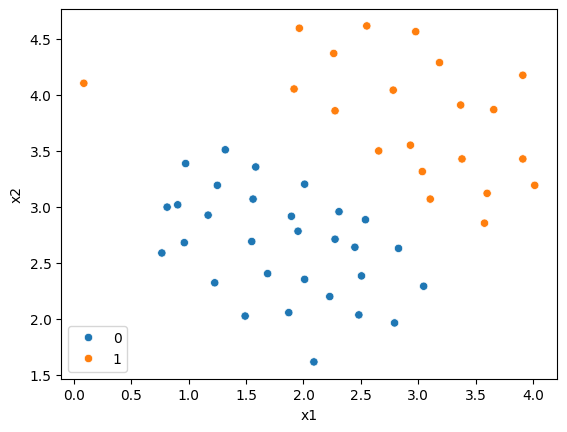

In [15]:


# pinta un scatter con los puntos y el color según la y
# pon la leyenda abajo a la izquierda

sns.scatterplot(df, x='x1', y='x2', hue="y")
plt.legend(loc="lower left")

Notice that there is one outlier positive example that sits apart from the others.  The classes are still linearly separable but it's a very tight fit.  We're going to train a linear support vector machine to learn the class boundary.

#### 5. LinearSVC
Declare a Linear SVC with the hyperparamenters:

```Python
LinearSVC(C=1, loss='hinge', max_iter=10000)
```

In [16]:
from sklearn.svm import LinearSVC

svc = LinearSVC(C=1, loss='hinge', max_iter=10000)

#### 6. Try the performance (score)
For the first experiment we'll use C=1 and see how it performs.

In [20]:
# no hace falta separar en train y en test por simplicidad
# entrena el modelo con X, y
# calcula el score por defecto del modelo

from sklearn.svm import LinearSVC

svc_1 = LinearSVC(C=1, loss='hinge', max_iter=10000)

X = df[['x1', 'x2']]
y = df['y']

svc_1.fit(X, y)

svc_1.score(X, y)

0.9803921568627451

It appears that it mis-classified the outlier.

#### 7. Increase the value of C until you get a perfect classifier

In [21]:
# equivalente a lo anterior pero subiendo el hiperparámetro C

svc_2 = LinearSVC(C=100, loss='hinge', max_iter=10000)

svc_2.fit(X, y)

svc_2.score(X, y)

c:\Users\esthe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


0.9803921568627451

This time we got a perfect classification of the training data, however by increasing the value of C we've created a decision boundary that is no longer a natural fit for the data.  We can visualize this by looking at the confidence level for each class prediction, which is a function of the point's distance from the hyperplane.

#### 8. Plot Decission Function
Get the `decision_function()` output for the first model. Plot a scatterplot with X1, X2 and a range of colors based on `decision_function()`

In [22]:
# obtén la función de decisión del modelo

decision = svc_1.decision_function(X)

decision

array([ 0.8027536 ,  0.38383438,  1.37739715,  0.52108414,  0.33331667,
        0.86860433,  0.68643245,  1.61110593,  0.83439567,  1.1670449 ,
        1.0731458 ,  0.22972363,  0.33175131,  0.79572695,  0.31571696,
        1.27399757,  1.21009623,  0.99987828,  0.56465611,  0.3898102 ,
       -0.43529056, -0.30886739, -0.68627371, -0.55403595, -0.33252705,
       -0.29385833, -0.44071825, -0.98399638, -0.68564283, -1.32848562,
       -1.00380132, -1.49231724, -0.61143703, -0.68346314, -1.00005248,
       -1.15275392, -1.57841932, -1.3559977 , -1.03241532, -1.18506048,
       -0.77143372, -0.76694524, -0.46652455, -1.        , -0.51034855,
       -0.85864291, -1.55902915, -0.25490914, -1.11366664, -1.54720686,
       -0.70997771])

Text(0, 0.5, 'x2')

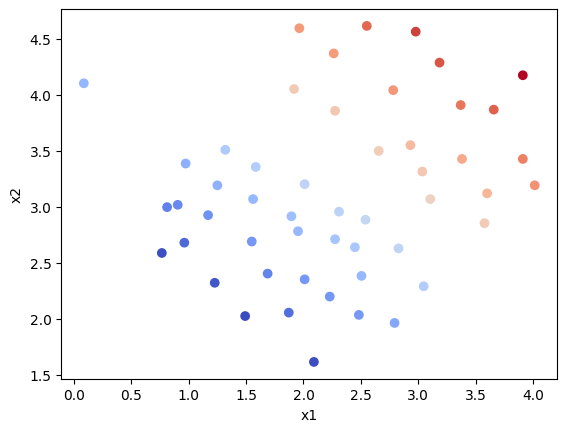

In [23]:


# usa un scatter para pintar los puntos, usa en el parámetro c del scatterplot la función de decisión
# el color puede ser "coolwarm"

plt.scatter(df['x1'], df['x2'], c=decision, cmap='coolwarm')

plt.xlabel('x1')
plt.ylabel('x2')

#### 9. Do the same with the second model

In [24]:
# equivalente pero con el segundo modelo

conf_level = svc_2.decision_function(X)
conf_level

array([ 4.44341241,  2.24751835,  6.33606979,  2.37736202,  1.        ,
        3.15674841,  2.79939776,  6.70097512,  3.95532839,  5.68614538,
        4.61235788,  0.8839169 ,  2.28210597,  4.17785702,  1.63426444,
        5.69253492,  5.02728854,  3.84971414,  2.06127852,  1.68439628,
       -1.03632952, -0.7778406 , -2.49360158, -2.12746871, -1.12106355,
       -1.34359218, -2.19887703, -4.29434796, -2.92046131, -5.4267543 ,
       -4.01957547, -5.6895353 , -2.09973479, -2.17605371, -3.64394483,
       -4.46375759, -6.2971485 , -4.84774492, -3.49941227, -3.93392769,
       -2.12980297, -2.3237664 , -0.97606683, -4.17197651, -2.05805665,
       -3.95139097, -6.67232955, -0.93806227, -3.67254864, -5.5874808 ,
       -1.1536543 ])

<Axes: xlabel='x1', ylabel='x2'>

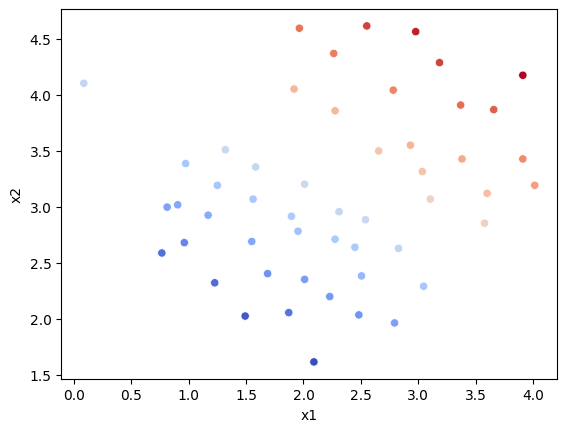

In [25]:
# equivalente con el segundo modelo

sns.scatterplot(df, x='x1', y='x2', c=conf_level, cmap="coolwarm")

y = ax1 + bx2 + c

0 = ax1 + bx2 + c

x2 = -ax1/b - c/b

In [26]:
# coeficientes del segundo modelo

svc_2.coef_

array([[1.982103 , 3.8169491]])

In [27]:
# intercept del segundo modelo

svc_2.intercept_

array([-16.99158549])

In [28]:
a = svc_2.coef_[0][0]
b = svc_2.coef_[0][1]
c = svc_2.intercept_

In [29]:
x_points = df['x1'].sort_values()
y_points = -a/b * x_points - c/b

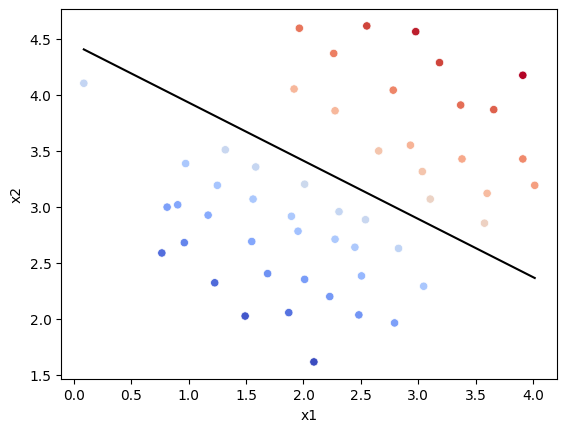

In [30]:


# pinta los puntos con su nivel de confianza
# añade la recta que es la frontera de separación

conf_level = svc_2.decision_function(X)
sns.scatterplot(df, x='x1', y='x2', c=conf_level, cmap="coolwarm")
plt.plot(x_points, y_points, color="black")

In [31]:
a = svc_1.coef_[0][0]
b = svc_1.coef_[0][1]
c = svc_1.intercept_
x_points = df['x1'].sort_values()
y_points = -a/b * x_points - c/b

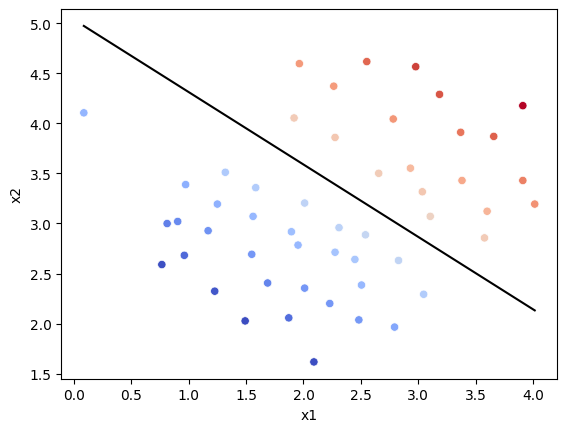

In [32]:
# equivalente con el modelo 1

conf_level = svc_1.decision_function(X)

sns.scatterplot(data=df, x='x1', y='x2', c=conf_level, cmap='coolwarm')

plt.plot(x_points, y_points, color='black')

Now we're going to move from a linear SVM to one that's capable of non-linear classification using kernels.  We're first tasked with implementing a gaussian kernel function.  Although scikit-learn has a gaussian kernel built in, for transparency we'll implement one from scratch.

## Exercise 2

That result matches the expected value from the exercise.  Next we're going to examine another data set, this time with a non-linear decision boundary.

#### 1. Load the data `ejer_1_data2.mat`

In [33]:
# descarga los datos y mira sus claves

import scipy.io as sio

mat2 = sio.loadmat('ejer_1_data2.mat')

mat2.keys()

dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])

#### 2. Create a DataFrame with the features and target

In [34]:
# crea el df
# muestra su head

import pandas as pd

df = pd.DataFrame(mat2['X'], columns=['x1', 'x2'])

df['y'] = mat2['y']

df.head()

,x1,x2,y
0,0.107143,0.603070,1
1,0.093318,0.649854,1
2,0.097926,0.705409,1
3,0.155530,0.784357,1
4,0.210829,0.866228,1


In [35]:
# la info del df

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 863 entries, 0 to 862
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      863 non-null    float64
 1   x2      863 non-null    float64
 2   y       863 non-null    uint8  
dtypes: float64(2), uint8(1)
memory usage: 14.5 KB


In [37]:
# describe del df

df.describe()

,x1,x2,y
count,863.000000,863.000000,863.000000
mean,0.503414,0.694304,0.556199
std,0.254967,0.158884,0.497120
min,0.044931,0.402632,0.000000
25%,0.292627,0.557018,0.000000
50%,0.512673,0.693713,1.000000
75%,0.699309,0.830409,1.000000
max,0.998848,0.988596,1.000000


#### 3. Plot a scatterplot with the data

<Axes: xlabel='x1', ylabel='x2'>

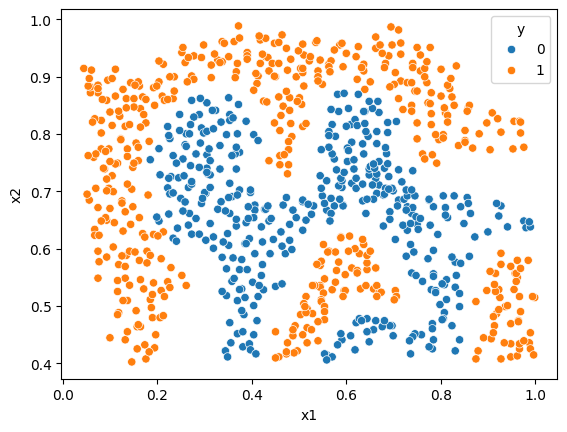

In [38]:
# scatterplot y en hue la y

sns.scatterplot(df, x='x1', y='x2', hue="y")

For this data set we'll build a support vector machine classifier using the built-in RBF kernel and examine its accuracy on the training data.  To visualize the decision boundary, this time we'll shade the points based on the predicted probability that the instance has a negative class label.  We'll see from the result that it gets most of them right.

Text(0, 0.5, 'x2')

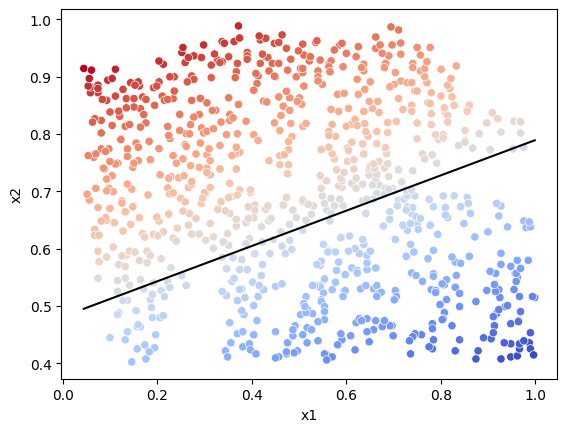

In [39]:
from sklearn.svm import LinearSVC
import seaborn as sns
import matplotlib.pyplot as plt

X = df[['x1', 'x2']]
y = df['y']

# haz un svc con C = 1, loss = "hinge" y max_iter = 10000
# entrénalo y calcula su score por defecto

svc_3 = LinearSVC(C=1, loss='hinge', max_iter=10000)

svc_3.fit(X, y)

svc_3.score(X, y)

a = svc_3.coef_[0][0]
b = svc_3.coef_[0][1]
c = svc_3.intercept_

x_points = df['x1'].sort_values()
y_points = -a/b * x_points - c/b

# saca el nivel de confianza
conf_level = svc_3.decision_function(X)

# pinta un scatter con ese nivel de confianza y color "coolwarm"
sns.scatterplot(data=df, x='x1', y='x2', c=conf_level, cmap='coolwarm')

# pinta la frontera de separación de las clases
plt.plot(x_points, y_points, color='black')

plt.xlabel('x1')
plt.ylabel('x2')



#### 4. Declare a SVC with this hyperparameters
```Python
SVC(C=100, gamma=10, probability=True)
```


In [40]:
from sklearn.svm import SVC

svc = SVC(C=100, gamma=10, probability=True)

#### 5. Fit the classifier and get the score

In [41]:
svc.fit(X, y)

svc.score(X, y)

0.9698725376593279

#### 6. Plot the scatter plot and probability of predicting 0 with a [sequential color](https://matplotlib.org/3.1.1/tutorials/colors/colormaps.html)

In [42]:
# pista: tienes que obtener la probabilidad de ser 0

probs = svc.predict_proba(X)

probs

array([[3.0000009e-14, 1.0000000e+00],
       [3.0000009e-14, 1.0000000e+00],
       [3.0000009e-14, 1.0000000e+00],
       ...,
       [3.0000009e-14, 1.0000000e+00],
       [3.0000009e-14, 1.0000000e+00],
       [3.0000009e-14, 1.0000000e+00]], shape=(863, 2))

Text(0, 0.5, 'x2')

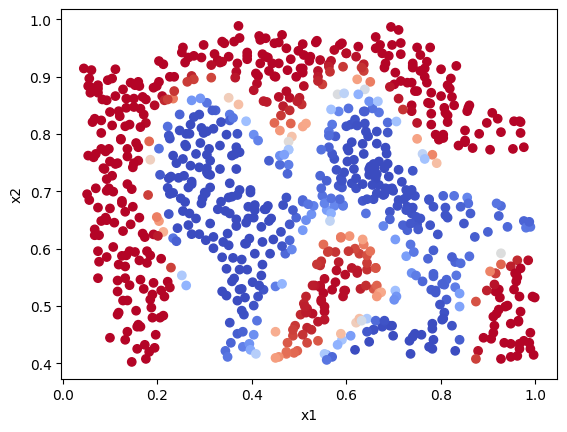

In [46]:
# haz un scatter para los puntos y pon el color según la probabilidad de ser 1

y_pred_proba = svc.predict_proba(X)

plt.scatter(df['x1'], df['x2'], c=y_pred_proba[:,1], cmap="coolwarm")

plt.xlabel('x1')
plt.ylabel('x2')

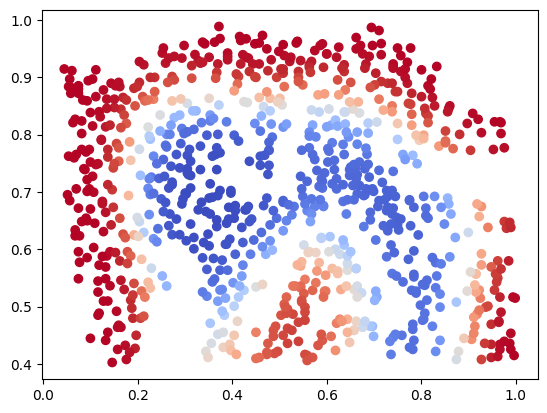

In [ ]:
svc_5 = SVC(C=1, gamma=10, probability=True)
svc_5.fit(X, y)
svc_5.score(X, y)
y_pred_proba = svc_5.predict_proba(X)
plt.scatter(df['x1'], df['x2'], c=y_pred_proba[:,1], cmap="coolwarm")

In [45]:
svc_6 = SVC(C=10000, gamma=10, probability=True)
# equivalente

In [47]:

# importa train_test_split y GridSearchCV
# divide en train y en test con semilla de 42 y 20% para el test

from sklearn.model_selection import train_test_split, GridSearchCV

X = df[['x1', 'x2']]
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


Text(0, 0.5, 'x2')

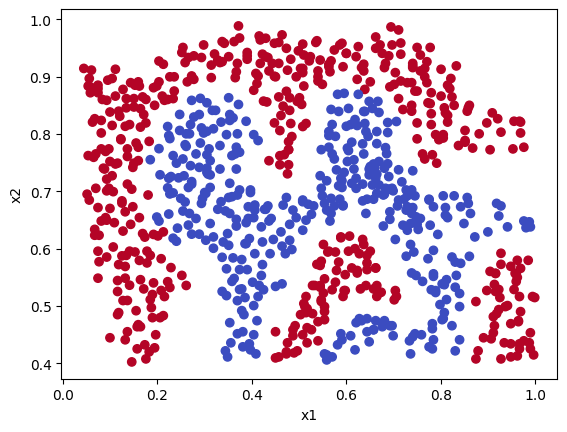

In [48]:

# haz un scatter con todo X, el color viene de y y el color es "coolwarm"

plt.scatter(df['x1'], df['x2'], c=y, cmap='coolwarm')

plt.xlabel('x1')
plt.ylabel('x2')

Text(0, 0.5, 'x2')

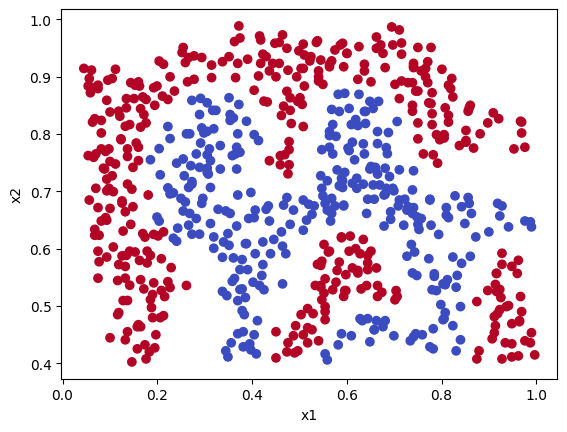

In [49]:
# equivalente con X train

plt.scatter(X_train['x1'], X_train['x2'], c=y_train, cmap='coolwarm')

plt.xlabel('x1')
plt.ylabel('x2')

Text(0, 0.5, 'x2')

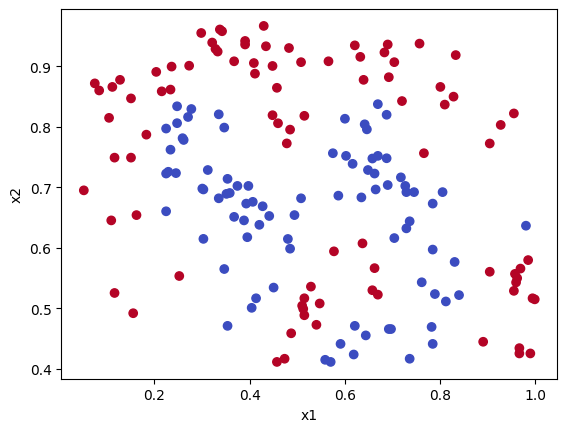

In [50]:
# equivalente con X test

plt.scatter(X_test['x1'], X_test['x2'], c=y_test, cmap='coolwarm')

plt.xlabel('x1')
plt.ylabel('x2')

In [51]:
# hiperparámetros: kernel rbf, kernel polynomial, C puede valer 1, 10, 50, 100

from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'kernel': ['rbf', 'poly'],
    'C': [1, 10, 50, 100]
}

gs = GridSearchCV(
    SVC(probability=True),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=2
)

gs.fit(X_train, y_train)

print(gs.best_estimator_)
print(gs.best_params_)
print(gs.best_score_)

# haz un gridsearchcv con 5 folds, scoring accuracy y verbose 2, entrénalo con train



print(gs.best_estimator_)
print(gs.best_params_)
print(gs.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END ....................................C=1, kernel=rbf; total time=   0.0s
[CV] END ....................................C=1, kernel=rbf; total time=   0.0s
[CV] END ....................................C=1, kernel=rbf; total time=   0.0s
[CV] END ....................................C=1, kernel=rbf; total time=   0.0s
[CV] END ....................................C=1, kernel=rbf; total time=   0.0s
[CV] END ...................................C=1, kernel=poly; total time=   0.4s
[CV] END ...................................C=1, kernel=poly; total time=   0.4s
[CV] END ...................................C=1, kernel=poly; total time=   0.3s
[CV] END ...................................C=1, kernel=poly; total time=   0.4s
[CV] END ...................................C=1, kernel=poly; total time=   0.4s
[CV] END ...................................C=10, kernel=rbf; total time=   0.0s
[CV] END ...................................C=10,

KeyboardInterrupt: 

In [56]:
gs.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END ....................................C=1, kernel=rbf; total time=   0.0s
[CV] END ....................................C=1, kernel=rbf; total time=   0.0s
[CV] END ....................................C=1, kernel=rbf; total time=   0.0s
[CV] END ....................................C=1, kernel=rbf; total time=   0.0s
[CV] END ....................................C=1, kernel=rbf; total time=   0.0s
[CV] END ...................................C=1, kernel=poly; total time=   0.3s
[CV] END ...................................C=1, kernel=poly; total time=   0.3s
[CV] END ...................................C=1, kernel=poly; total time=   0.3s
[CV] END ...................................C=1, kernel=poly; total time=   0.3s
[CV] END ...................................C=1, kernel=poly; total time=   0.4s
[CV] END ...................................C=10, kernel=rbf; total time=   0.0s
[CV] END ...................................C=10,

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(probability=True)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [1, 10, ...], 'kernel': ['rbf', 'poly']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and

In [57]:
# mira el score en test

gs.score(X_test, y_test)

0.9421965317919075

In [58]:
# usa pickle y guarda el estimador GridsearchCV en un archivo

import pickle

with open('modelo.pkl', 'wb') as file:
    pickle.dump(gs.best_estimator_, file)

In [59]:
# lee usando pickle el archivo

with open('modelo.pkl', 'rb') as file:
    modelo_importado = pickle.load(file)

modelo_importado

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [60]:
modelo_importado

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [61]:
# predice [1,3] 

modelo_importado.predict([[1, 3]])

c:\Users\esthe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([1], dtype=uint8)

In [62]:
# Obtén las probabilidades de ser 1 en test

y_pred_proba = modelo_importado.predict_proba(X_test)

y_pred_proba[:, 1]

array([9.75104844e-01, 3.35374916e-01, 1.00000000e+00, 4.67662754e-03,
       2.28788786e-05, 9.99995793e-01, 2.78865506e-03, 1.33798391e-01,
       2.43548383e-02, 9.99998962e-01, 1.00000000e+00, 9.42658725e-01,
       3.07067013e-02, 1.00000000e+00, 3.01989561e-02, 1.31007228e-02,
       3.48649629e-05, 5.93738208e-05, 8.54881433e-02, 9.61505514e-01,
       1.15526095e-02, 4.63404132e-02, 1.50361628e-02, 4.23152979e-01,
       9.96662896e-01, 9.96438472e-01, 1.44710355e-02, 9.88363931e-01,
       1.00000000e+00, 7.64110410e-01, 7.85449806e-02, 1.00000000e+00,
       6.65378915e-01, 1.70950941e-03, 9.99994013e-01, 9.92115884e-01,
       5.49365589e-03, 9.99999378e-01, 8.84871530e-02, 9.77387265e-01,
       1.00000000e+00, 9.99999984e-01, 1.00000000e+00, 4.67021227e-01,
       2.75222634e-01, 5.60366537e-01, 9.99999652e-01, 8.04676541e-01,
       1.95931226e-02, 3.60578232e-04, 5.63259545e-02, 7.12294429e-02,
       1.00000000e+00, 3.46341462e-02, 9.99998973e-01, 7.56310089e-01,
      

Text(0, 0.5, 'x2')

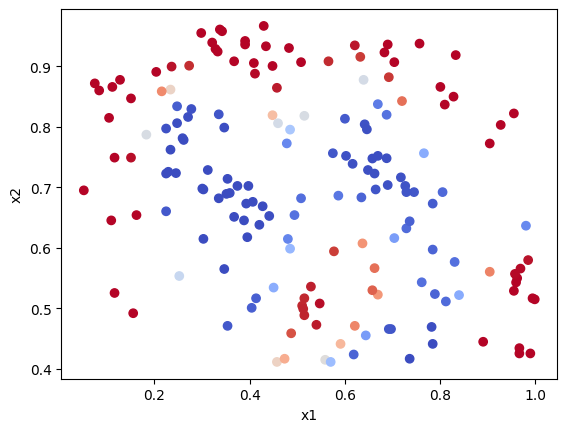

In [63]:
# haz un scatterplot y pinta esos puntos de test con sus probabilidades de ser 1

plt.scatter(
    X_test['x1'],
    X_test['x2'],
    c=y_pred_proba[:, 1],
    cmap="coolwarm"
)

plt.xlabel('x1')
plt.ylabel('x2')

In [66]:
# EXTRA

# usa pipeline y PolynomialFeatures
# prueba grados de 2 a 6
# el hiperparámetro C del svc entre -1 y 2, 5 valor espaciados logarítmicamente
# 5 folds
# scoring accuracy


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
import numpy as np

pipe = Pipeline([
    ('poly', PolynomialFeatures()),
    ('svc', SVC())
])

param_grid = {
    'poly__degree': [2, 3, 4, 5, 6],
    'svc__C': np.logspace(-1, 2, 5)
}

gs_poly = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='accuracy'
)

gs_poly.fit(X_train, y_train)

print(gs_poly.best_estimator_)
print(gs_poly.best_params_)
print(gs_poly.best_score_)

Pipeline(steps=[('poly', PolynomialFeatures()),
                ('svc', SVC(C=np.float64(100.0)))])
{'poly__degree': 2, 'svc__C': np.float64(100.0)}
0.9188405797101449


In [67]:
# con pipelines y GridSearchCV
# polynomial puede ser grado 2, 3 o Ninguno
# C del svc espaciado logarítmico entre -1 y 2, 5 valores
# el kernel del svc lineal o gaussiano

# 5 folds, scoring accuracy, verbose 2



print(gs.best_estimator_)
print(gs.best_params_)
print(gs.best_score_)

final_model = gs.best_estimator_
final_model.fit(X_train, y_train)
final_model.score(X_test, y_test)

SVC(C=100, probability=True)
{'C': 100, 'kernel': 'rbf'}
0.9536231884057973


0.9421965317919075